# QQQ Volatility Forecasting: Exploratory Data Analysis, Features and Targets

Notebook นี้อธิบายพฤติกรรมราคา Features ทั้ง 8 ตัว Regression/Classification Targets และ leakage-aware time-series split โดยอ่านเฉพาะ pipeline artifacts ที่มีอยู่แล้ว ไม่มี Scaling และไม่มี Model Training

## 1. Problem Statement

ใช้ข้อมูลราคาและปริมาณซื้อขายย้อนหลังของ QQQ เพื่อทำนายความผันผวนใน 5 trading days ข้างหน้า

- **Regression:** ทำนายค่าความผันผวนล่วงหน้าแบบต่อเนื่อง
- **Classification:** จำแนก Normal กับ High Volatility

Features หลายกลุ่มอาจมีความสัมพันธ์ร่วมกันและอาจไม่เป็นเส้นตรงทั้งหมด จึงเหมาะกับการเปรียบเทียบโมเดลอย่างเป็นระบบในขั้นต่อไป อย่างไรก็ตามผลลัพธ์ไม่สามารถรับประกันผลตอบแทนการลงทุนได้

## 2. Environment, Inputs and Reports

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

current = Path.cwd().resolve()
project_root = current.parent if current.name == "notebooks" else current
if not (project_root / "config.py").is_file() or not (project_root / "src").is_dir():
    raise FileNotFoundError(
        f"Could not resolve project root from {current}; expected config.py and src/."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

figure_dir = project_root / "outputs" / "figures" / "data_preparation"
figure_dir.mkdir(parents=True, exist_ok=True)

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as source_file:
        for chunk in iter(lambda: source_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest().upper()

def require_files(paths: dict[str, Path]) -> None:
    missing = [f"{name}: {path}" for name, path in paths.items() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Missing required pipeline artifacts:\n" + "\n".join(missing))

def reject_adjusted_close(df: pd.DataFrame, dataset_name: str) -> None:
    forbidden = sorted({"Adj Close", "adj_close", "Adjusted Close"}.intersection(df.columns))
    if forbidden:
        raise ValueError(f"{dataset_name} contains forbidden columns: {forbidden}")

from config import (
    CLASSIFICATION_THRESHOLD_REPORT_PATH,
    CLEAN_DATA_PATH,
    DATA_SPLIT_REPORT_PATH,
    FEATURE_DATA_PATH,
    FEATURE_REPORT_PATH,
    REGRESSION_TARGET_DATA_PATH,
    TEST_DATA_PATH,
    TEST_LABELED_DATA_PATH,
    TRAIN_DATA_PATH,
    TRAIN_LABELED_DATA_PATH,
    VALIDATION_DATA_PATH,
    VALIDATION_LABELED_DATA_PATH,
)
from src.build_features import ANNUALIZATION_FACTOR, FEATURE_COLUMNS
from src.build_targets import CLASSIFICATION_TARGET, TARGET_COLUMN

input_sources = {
    "clean_data": Path(CLEAN_DATA_PATH),
    "feature_data": Path(FEATURE_DATA_PATH),
    "regression_target_data": Path(REGRESSION_TARGET_DATA_PATH),
    "train": Path(TRAIN_DATA_PATH),
    "validation": Path(VALIDATION_DATA_PATH),
    "test": Path(TEST_DATA_PATH),
    "train_labeled": Path(TRAIN_LABELED_DATA_PATH),
    "validation_labeled": Path(VALIDATION_LABELED_DATA_PATH),
    "test_labeled": Path(TEST_LABELED_DATA_PATH),
    "feature_report": Path(FEATURE_REPORT_PATH),
    "data_split_report": Path(DATA_SPLIT_REPORT_PATH),
    "classification_threshold_report": Path(CLASSIFICATION_THRESHOLD_REPORT_PATH),
}
require_files(input_sources)
checksums_before = {name: sha256(path) for name, path in input_sources.items()}
display(pd.DataFrame.from_dict(checksums_before, orient="index", columns=["SHA-256 before"]))

mkdir -p failed for path C:\Users\ADMIN\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\ADMIN\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\ADMIN\AppData\Local\Temp\matplotlib-6dg6ttxk because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,SHA-256 before
clean_data,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...
feature_data,5020287D8A5D5963F9E0A894D5581D2174B513A1C0B493...
regression_target_data,557B6B2F6EDB560A9CF5F9A10208351C2C11BFAA00C49E...
train,E00CC9E500C463A46BBA3A986602B99D13B569237FB895...
validation,6B7E92C6A0C1FA3D150573C53B4D6DDE1FD7506C04F363...
test,51E4719DEDF627129557147F67C9385C2B750AC409D919...
train_labeled,424F1BDA5C4211AC58546DA992408D373D874A0F65A509...
validation_labeled,B84A5FA31FE1AFC6841528F8E5F0C8532B07E2BDA8B80B...
test_labeled,5E8AC488CB895A8899ABD9B3AE9193B4DC6EBDA2E77B79...
feature_report,50E565284641E671A7C7958246D9D54E82294659B7A8EC...


In [2]:
dataset_names = [
    "clean_data", "feature_data", "regression_target_data",
    "train", "validation", "test",
    "train_labeled", "validation_labeled", "test_labeled",
]
datasets = {name: pd.read_csv(input_sources[name]) for name in dataset_names}
for name, frame in datasets.items():
    frame["Date"] = pd.to_datetime(frame["Date"], errors="raise")
    if "Close" not in frame.columns:
        raise ValueError(f"{name} is missing Close")
    reject_adjusted_close(frame, name)

with input_sources["feature_report"].open("r", encoding="utf-8") as handle:
    feature_report = json.load(handle)
with input_sources["data_split_report"].open("r", encoding="utf-8") as handle:
    split_report = json.load(handle)
with input_sources["classification_threshold_report"].open("r", encoding="utf-8") as handle:
    classification_report = json.load(handle)

required_feature_columns = ["Date", "Close", *FEATURE_COLUMNS]
required_target_columns = [*required_feature_columns, TARGET_COLUMN]
for name in ("feature_data", "regression_target_data", "train", "validation", "test"):
    required = required_feature_columns if name == "feature_data" else required_target_columns
    missing = [column for column in required if column not in datasets[name].columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")
for name in ("train_labeled", "validation_labeled", "test_labeled"):
    missing = [column for column in [*required_target_columns, CLASSIFICATION_TARGET] if column not in datasets[name].columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

overview = pd.DataFrame({
    name: {
        "rows": len(frame),
        "columns": frame.shape[1],
        "start_date": frame["Date"].min().strftime("%Y-%m-%d"),
        "end_date": frame["Date"].max().strftime("%Y-%m-%d"),
    }
    for name, frame in datasets.items()
}).T
display(overview)

,rows,columns,start_date,end_date
clean_data,2512,6,2016-08-31,2026-08-28
feature_data,2512,14,2016-08-31,2026-08-28
regression_target_data,2512,15,2016-08-31,2026-08-28
train,1733,15,2016-09-29,2023-08-18
validation,371,15,2023-08-28,2025-02-19
test,373,15,2025-02-27,2026-08-21
train_labeled,1733,16,2016-09-29,2023-08-18
validation_labeled,371,16,2023-08-28,2025-02-19
test_labeled,373,16,2025-02-27,2026-08-21


## 3. Close Price Over Time

กราฟนี้เป็น **descriptive analysis เท่านั้น** ไม่ได้ใช้เลือก Feature, ปรับ Threshold, เลือก Hyperparameter หรือปรับ Model

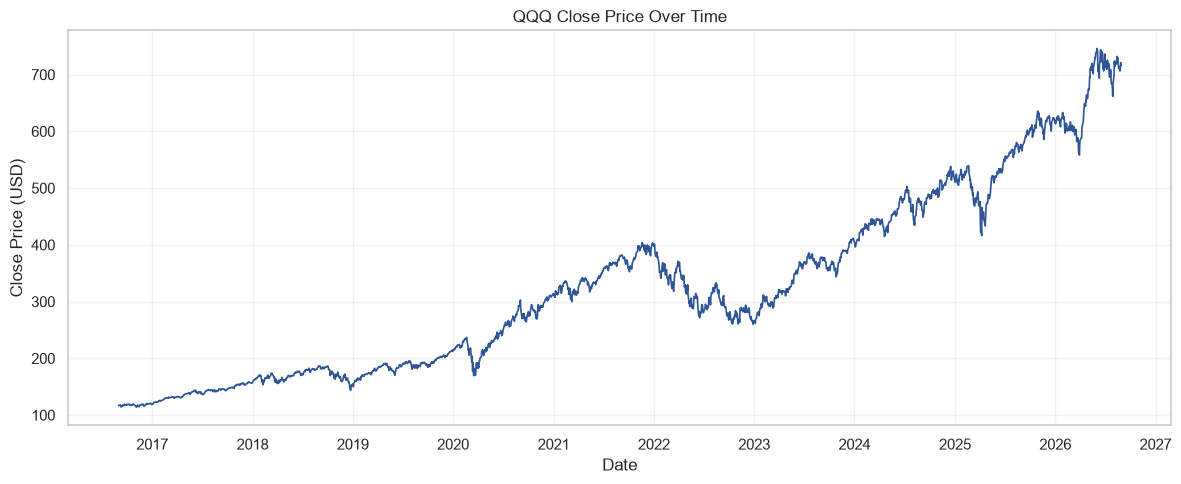

In [3]:
clean_df = datasets["clean_data"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(clean_df["Date"], clean_df["Close"], color="#2F5597", linewidth=1.2)
ax.set_title("QQQ Close Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.grid(alpha=0.25)
fig.tight_layout()
output_path = figure_dir / "02_close_price_over_time.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 4. Daily Return Analysis

ส่วนนี้ใช้ข้อมูลทั้งช่วงเพื่ออธิบายภาพรวมเชิงพรรณนาเท่านั้น ไม่ได้ใช้เลือก Feature, ปรับ Threshold, เลือก Hyperparameter หรือปรับ Model ค่า return ถูกเก็บเป็น decimal และแสดงบนกราฟเป็น percentage

,decimal,percentage
count,2511.000000,251100.000000
mean,0.000825,0.082499
std,0.014213,1.421282
min,-0.119788,-11.978788
1%,-0.039171,-3.917105
5%,-0.022650,-2.265028
25%,-0.005177,-0.517711
50%,0.001282,0.128239
75%,0.008011,0.801051
95%,0.021361,2.136130


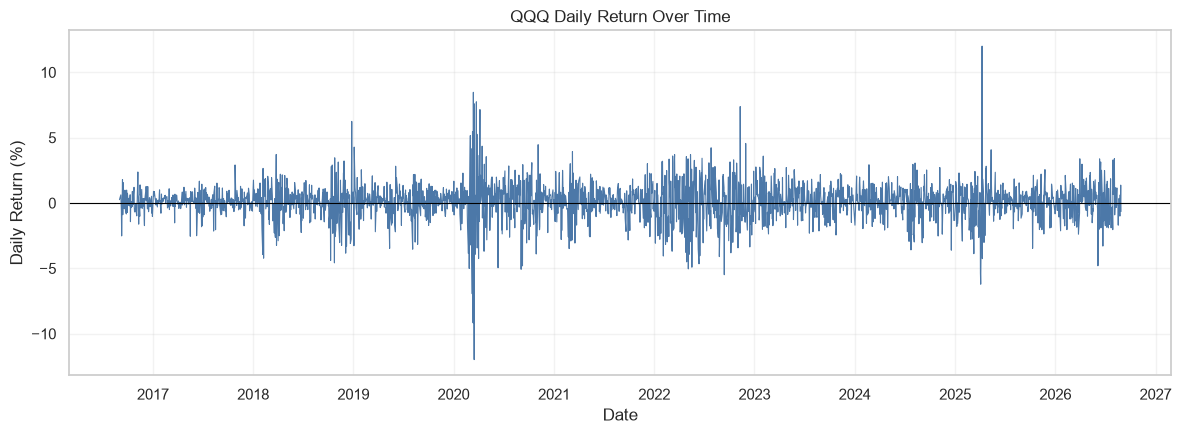

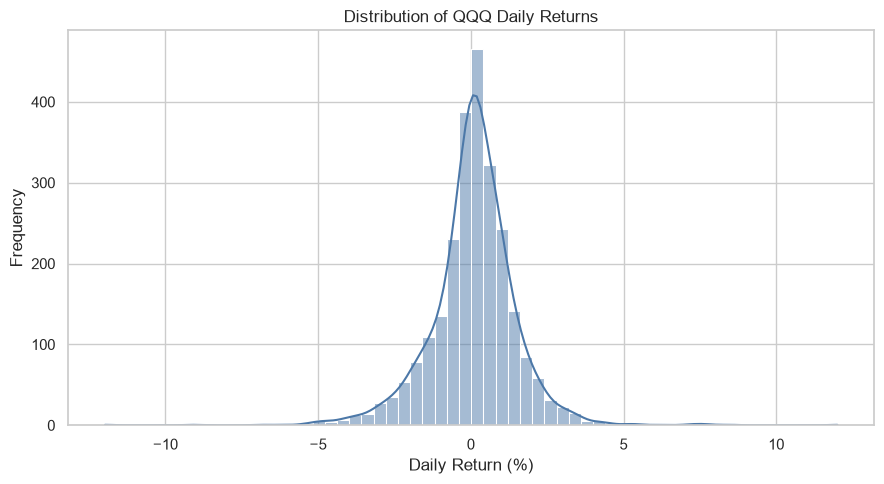

In [4]:
feature_df = datasets["feature_data"]
daily_return = feature_df["return_1d"].dropna()
return_summary = daily_return.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("decimal")
return_summary["percentage"] = return_summary["decimal"] * 100
display(return_summary)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(feature_df["Date"], feature_df["return_1d"] * 100, color="#4C78A8", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("QQQ Daily Return Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
ax.grid(alpha=0.25)
fig.tight_layout()
output_path = figure_dir / "03_daily_return_over_time.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(daily_return * 100, bins=60, kde=True, ax=ax, color="#4C78A8")
ax.set_title("Distribution of QQQ Daily Returns")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
fig.tight_layout()
output_path = figure_dir / "04_daily_return_distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 5. Historical Volatility Analysis

กราฟนี้เป็น descriptive analysis เท่านั้น ไม่ได้ใช้เลือก Feature, ปรับ Threshold, เลือก Hyperparameter หรือปรับ Model ทั้งสองเส้นเป็นข้อมูลย้อนหลัง ไม่ใช่ Target; 5-day volatility ตอบสนองเร็วกว่า ส่วน 20-day volatility เรียบกว่า

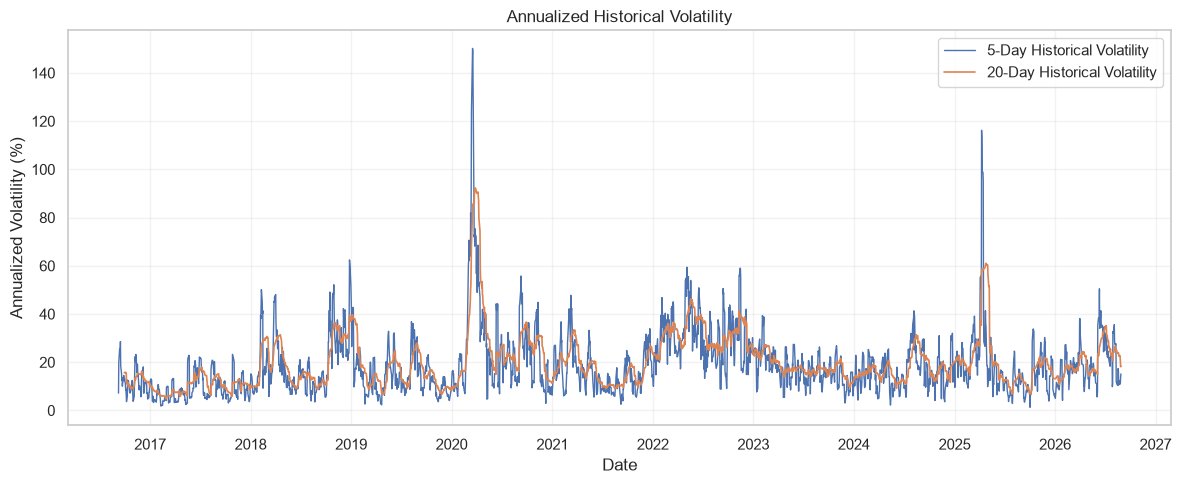

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(feature_df["Date"], feature_df["historical_volatility_5d"] * 100, label="5-Day Historical Volatility", linewidth=1.0)
ax.plot(feature_df["Date"], feature_df["historical_volatility_20d"] * 100, label="20-Day Historical Volatility", linewidth=1.2)
ax.set_title("Annualized Historical Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
output_path = figure_dir / "05_historical_volatility.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 6. Feature Definitions and Rationale

สูตรด้านล่างตรงกับ `src/build_features.py`; rolling windows ทุกตัวเป็น trailing window ที่ใช้ข้อมูลถึงวัน t เท่านั้น

In [6]:
feature_definitions = pd.DataFrame([
    ["return_1d", "Close[t] / Close[t-1] - 1", "1 trading row", "Daily return", "Short-run price movement", "Larger absolute moves may accompany volatility"],
    ["return_5d", "Close[t] / Close[t-5] - 1", "5 trading rows", "Cumulative five-row return", "Medium-short momentum/reversal", "Large moves may coincide with changing volatility"],
    ["historical_volatility_5d", "std(return_1d, 5, ddof=1) × sqrt(252)", "5 returns", "Fast trailing volatility", "Recent volatility state", "Often positively associated with future volatility persistence"],
    ["historical_volatility_20d", "std(return_1d, 20, ddof=1) × sqrt(252)", "20 returns", "Smoother trailing volatility", "Longer volatility state", "May capture persistent volatility regimes"],
    ["intraday_range", "(High - Low) / Close", "Current day", "Normalized intraday range", "Within-day uncertainty", "Wider ranges may accompany higher volatility"],
    ["sma_ratio_5_20", "SMA_5(Close) / SMA_20(Close)", "5 and 20 rows", "Short/medium price trend", "Trend state", "Departures from 1 may identify changing market conditions"],
    ["rsi_14", "Wilder RSI; SMA seed then recursive smoothing", "14 changes", "Bounded momentum oscillator", "Momentum and reversal state", "Extreme momentum may interact with future volatility"],
    ["volume_zscore_20", "(Volume - mean_20) / std_20(ddof=1)", "20 rows", "Unusual volume", "Trading-activity shock", "Abnormal activity may accompany volatility"],
], columns=["Feature", "Formula", "Lookback", "Meaning", "Reason for inclusion", "Expected relationship (hypothesis)"])
display(feature_definitions)
assert feature_report["annualization_factor"] == ANNUALIZATION_FACTOR
assert feature_report["feature_columns"] == FEATURE_COLUMNS

,Feature,Formula,Lookback,Meaning,Reason for inclusion,Expected relationship (hypothesis)
0,return_1d,Close[t] / Close[t-1] - 1,1 trading row,Daily return,Short-run price movement,Larger absolute moves may accompany volatility
1,return_5d,Close[t] / Close[t-5] - 1,5 trading rows,Cumulative five-row return,Medium-short momentum/reversal,Large moves may coincide with changing volatility
2,historical_volatility_5d,"std(return_1d, 5, ddof=1) × sqrt(252)",5 returns,Fast trailing volatility,Recent volatility state,Often positively associated with future volati...
3,historical_volatility_20d,"std(return_1d, 20, ddof=1) × sqrt(252)",20 returns,Smoother trailing volatility,Longer volatility state,May capture persistent volatility regimes
4,intraday_range,(High - Low) / Close,Current day,Normalized intraday range,Within-day uncertainty,Wider ranges may accompany higher volatility
5,sma_ratio_5_20,SMA_5(Close) / SMA_20(Close),5 and 20 rows,Short/medium price trend,Trend state,Departures from 1 may identify changing market...
6,rsi_14,Wilder RSI; SMA seed then recursive smoothing,14 changes,Bounded momentum oscillator,Momentum and reversal state,Extreme momentum may interact with future vola...
7,volume_zscore_20,(Volume - mean_20) / std_20(ddof=1),20 rows,Unusual volume,Trading-activity shock,Abnormal activity may accompany volatility


## 7. Train-Only Feature Distributions

การวิเคราะห์นี้อาจมีผลต่อการตัดสินใจเชิง Modeling จึงใช้ Train เท่านั้น

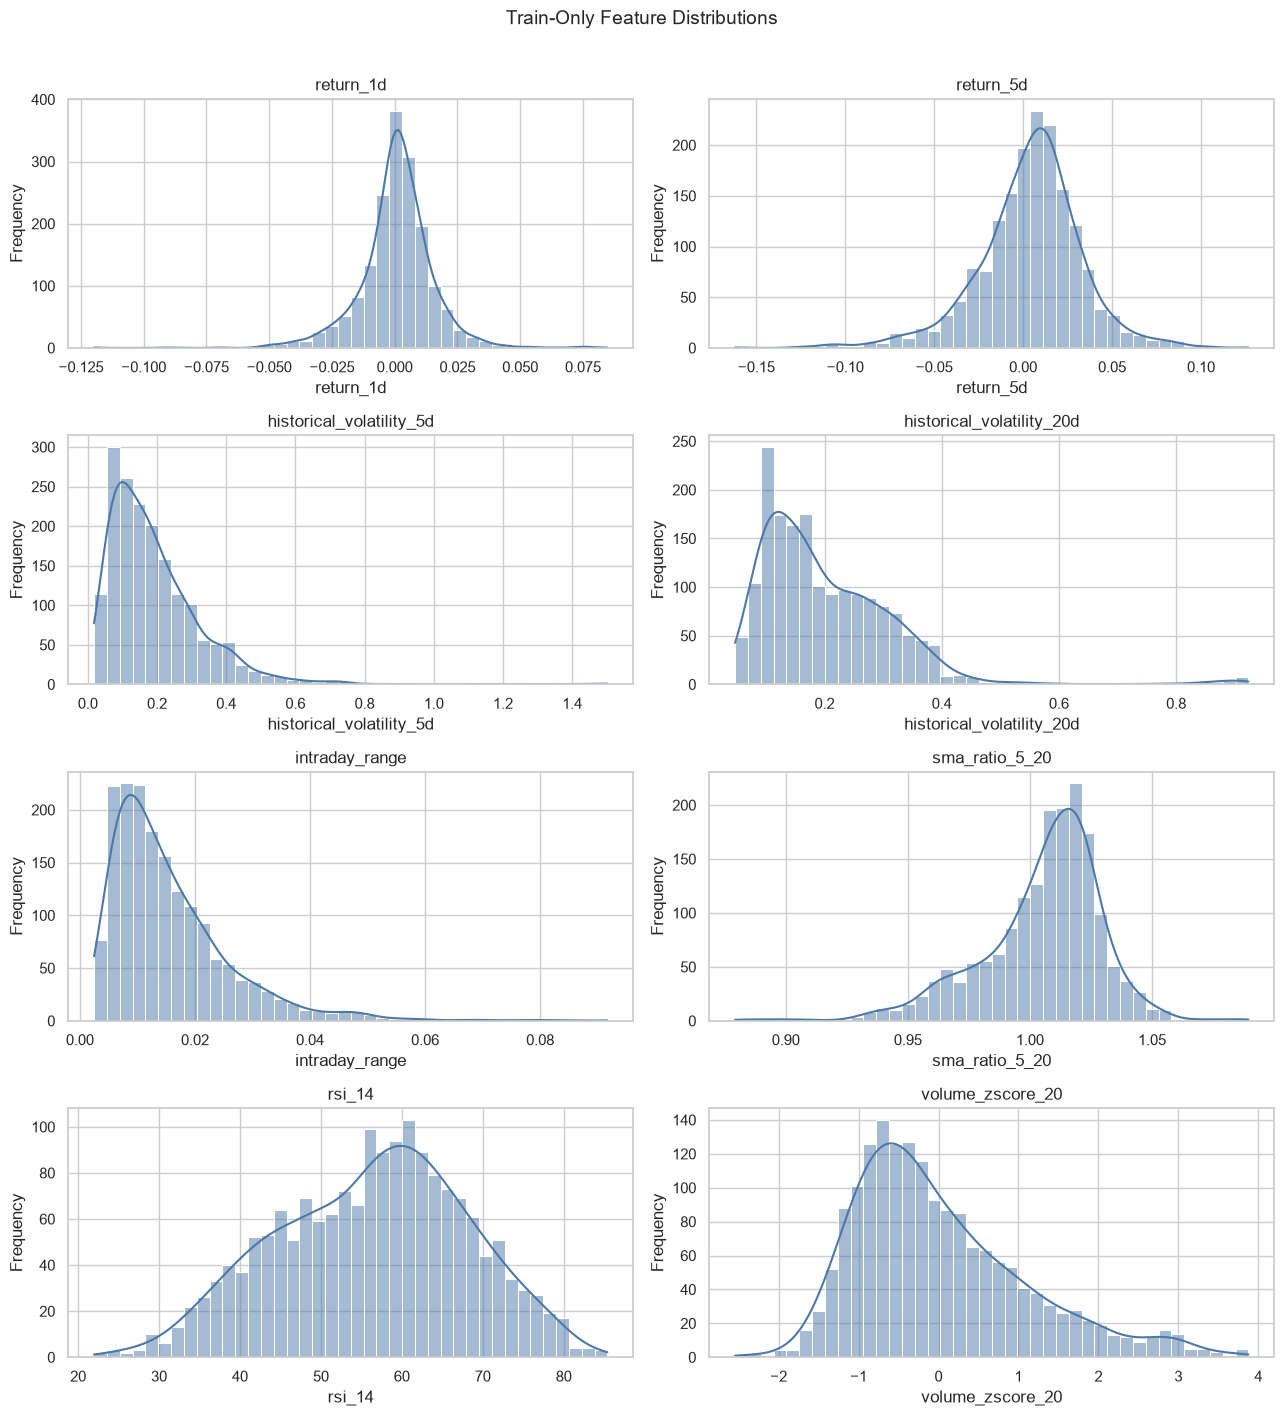

In [7]:
train_df = datasets["train"]
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
for column, ax in zip(FEATURE_COLUMNS, axes.flat, strict=True):
    sns.histplot(train_df[column], bins=40, kde=True, ax=ax, color="#4C78A8")
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
fig.suptitle("Train-Only Feature Distributions", y=1.01, fontsize=14)
fig.tight_layout()
output_path = figure_dir / "06_feature_distributions.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 8. Train-Only Feature Correlation

Correlation ไม่ได้หมายถึง causation และ correlation ต่ำไม่ได้แปลว่า feature ไม่มีประโยชน์ต่อโมเดลที่จับความสัมพันธ์ไม่เป็นเส้นตรงได้

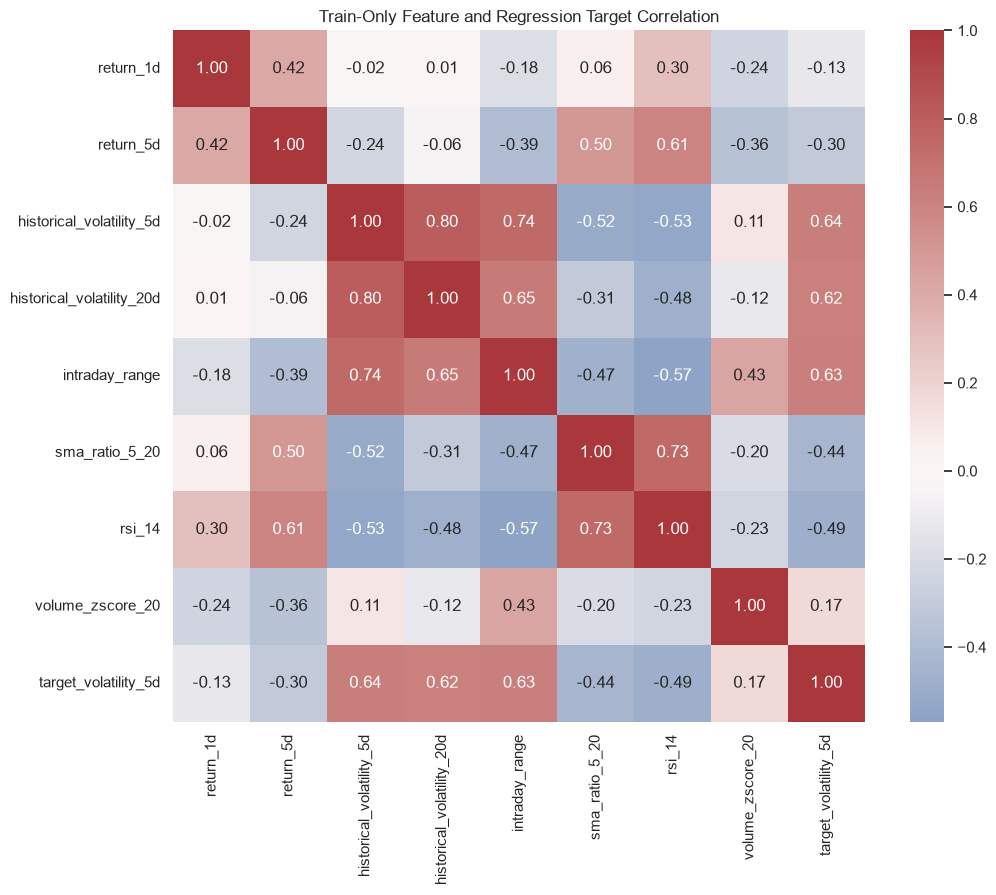

,correlation_with_target
target_volatility_5d,1.000000
historical_volatility_5d,0.635854
intraday_range,0.628909
historical_volatility_20d,0.616362
volume_zscore_20,0.169655
return_1d,-0.132105
return_5d,-0.302611
sma_ratio_5_20,-0.438581
rsi_14,-0.488166


In [8]:
corr_columns = [*FEATURE_COLUMNS, TARGET_COLUMN]
correlation = train_df[corr_columns].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Train-Only Feature and Regression Target Correlation")
fig.tight_layout()
output_path = figure_dir / "07_train_feature_correlation.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
display(correlation[TARGET_COLUMN].sort_values(ascending=False).to_frame("correlation_with_target"))

## 9. Regression Target

`target_volatility_5d[t] = std(return_1d[t+1], …, return_1d[t+5], ddof=1) × sqrt(252)`

Target ใช้ข้อมูลอนาคตเพื่อสร้างเฉลยสำหรับ training และไม่ถูกใช้เป็น feature ห้าแถวสุดท้ายของ regression-target artifact ไม่มีอนาคตครบจึงเป็น NaN ก่อน Modeling Data Preparation ค่า 0.25 หมายถึง annualized volatility 25% ไม่ได้หมายถึงราคาแกว่ง 25% ภายในห้าวัน

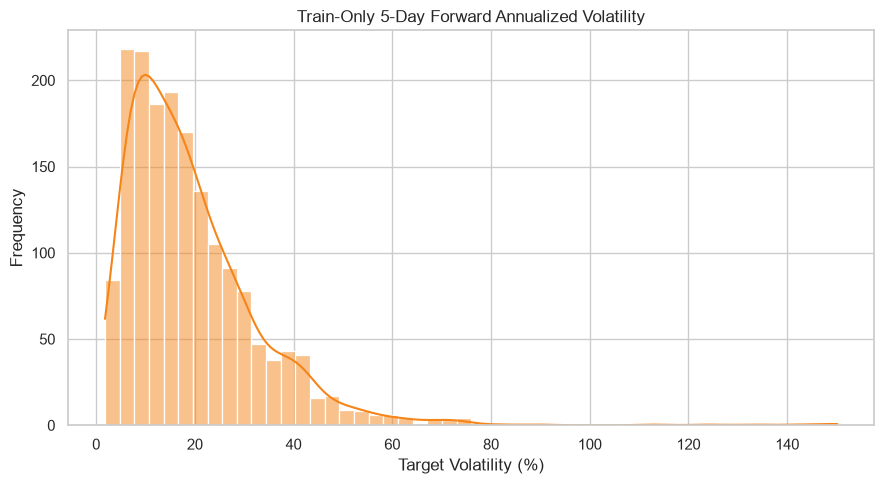

,annualized_percent
count,173300.000000
mean,19.375815
std,14.345559
min,1.795881
25%,9.416328
50%,16.164863
75%,25.305802
max,150.169268


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(train_df[TARGET_COLUMN] * 100, bins=50, kde=True, ax=ax, color="#F58518")
ax.set_title("Train-Only 5-Day Forward Annualized Volatility")
ax.set_xlabel("Target Volatility (%)")
ax.set_ylabel("Frequency")
fig.tight_layout()
output_path = figure_dir / "08_train_regression_target_distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
display((train_df[TARGET_COLUMN].describe() * 100).to_frame("annualized_percent"))

## 10. Classification Threshold and Target

Q75 ถูก fit จาก Train เท่านั้น ใช้ threshold เดียวกับทุก split และค่าเท่ากับ threshold เป็น Class 0

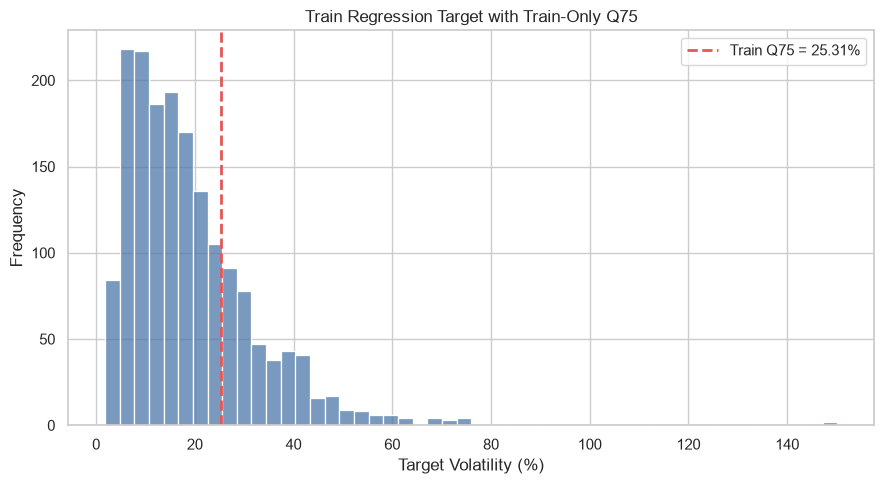

Verified train-only Q75: **0.2530580184684854** (25.305802%)

In [10]:
threshold = float(classification_report["threshold_decimal"])
verified_threshold = float(train_df[TARGET_COLUMN].quantile(0.75, interpolation="linear"))
if not np.isclose(threshold, verified_threshold, rtol=1e-12, atol=1e-15):
    raise ValueError("Classification report threshold does not match train-only Q75")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(train_df[TARGET_COLUMN] * 100, bins=50, ax=ax, color="#4C78A8")
ax.axvline(threshold * 100, color="#E45756", linestyle="--", linewidth=2, label=f"Train Q75 = {threshold * 100:.2f}%")
ax.set_title("Train Regression Target with Train-Only Q75")
ax.set_xlabel("Target Volatility (%)")
ax.set_ylabel("Frequency")
ax.legend()
fig.tight_layout()
output_path = figure_dir / "09_train_target_with_q75.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
display(Markdown(f"Verified train-only Q75: **{threshold:.16g}** ({threshold * 100:.6f}%)"))

## 11. Time-Series Split and Purging Gaps

Split รักษาลำดับเวลา ไม่มี shuffle และเว้น gap 5 trading rows เพื่อไม่ให้ future target window ของชุดก่อนหน้าเหลื่อมข้ามเข้า split ถัดไป

,Row count,Start date,End date,Normal count,High count,High ratio
Train,1733,2016-09-29,2023-08-18,1300,433,0.249856
Validation,371,2023-08-28,2025-02-19,337,34,0.091644
Test,373,2025-02-27,2026-08-21,300,73,0.19571


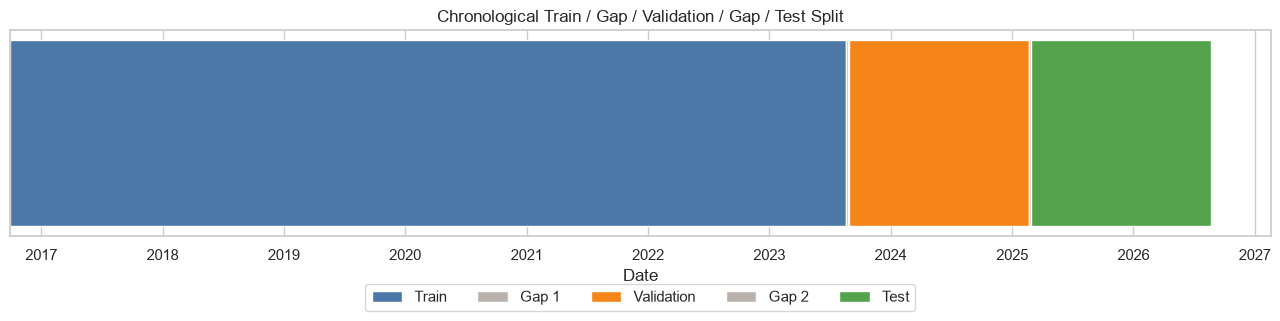

In [11]:
labeled_frames = {
    "Train": datasets["train_labeled"],
    "Validation": datasets["validation_labeled"],
    "Test": datasets["test_labeled"],
}
split_summary = pd.DataFrame({
    name: {
        "Row count": len(frame),
        "Start date": frame["Date"].min().strftime("%Y-%m-%d"),
        "End date": frame["Date"].max().strftime("%Y-%m-%d"),
        "Normal count": int(frame[CLASSIFICATION_TARGET].eq(0).sum()),
        "High count": int(frame[CLASSIFICATION_TARGET].eq(1).sum()),
        "High ratio": float(frame[CLASSIFICATION_TARGET].mean()),
    }
    for name, frame in labeled_frames.items()
}).T
display(split_summary)

segments = [
    ("Train", pd.Timestamp(split_report["date_ranges"]["train"]["start"]), pd.Timestamp(split_report["date_ranges"]["train"]["end"]), "#4C78A8"),
    ("Gap 1", pd.Timestamp(split_report["gap_dates"]["gap1"][0]), pd.Timestamp(split_report["gap_dates"]["gap1"][-1]), "#BAB0AC"),
    ("Validation", pd.Timestamp(split_report["date_ranges"]["validation"]["start"]), pd.Timestamp(split_report["date_ranges"]["validation"]["end"]), "#F58518"),
    ("Gap 2", pd.Timestamp(split_report["gap_dates"]["gap2"][0]), pd.Timestamp(split_report["gap_dates"]["gap2"][-1]), "#BAB0AC"),
    ("Test", pd.Timestamp(split_report["date_ranges"]["test"]["start"]), pd.Timestamp(split_report["date_ranges"]["test"]["end"]), "#54A24B"),
]
fig, ax = plt.subplots(figsize=(13, 3.5))
for label, start, end, color in segments:
    left = mdates.date2num(start)
    width = mdates.date2num(end) - left + 1
    ax.barh(0, width, left=left, height=0.55, color=color, label=label, edgecolor="white")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_yticks([])
ax.set_title("Chronological Train / Gap / Validation / Gap / Test Split")
ax.set_xlabel("Date")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.20))
fig.tight_layout()
output_path = figure_dir / "10_time_series_split.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 12. Class Distribution

Train มี High ใกล้ 25% ตาม train-only Q75 แต่ Validation/Test ไม่จำเป็นต้องเท่ากับ 25% และห้าม fit threshold ใหม่

ความแตกต่างของสัดส่วนอาจบ่งชี้ distribution shift หรือสภาวะตลาดที่แตกต่างกัน แต่หลักฐานนี้เพียงอย่างเดียวยังไม่เพียงพอสำหรับยืนยันการเปลี่ยน market regime และไม่ควรตีความเชิงสาเหตุ

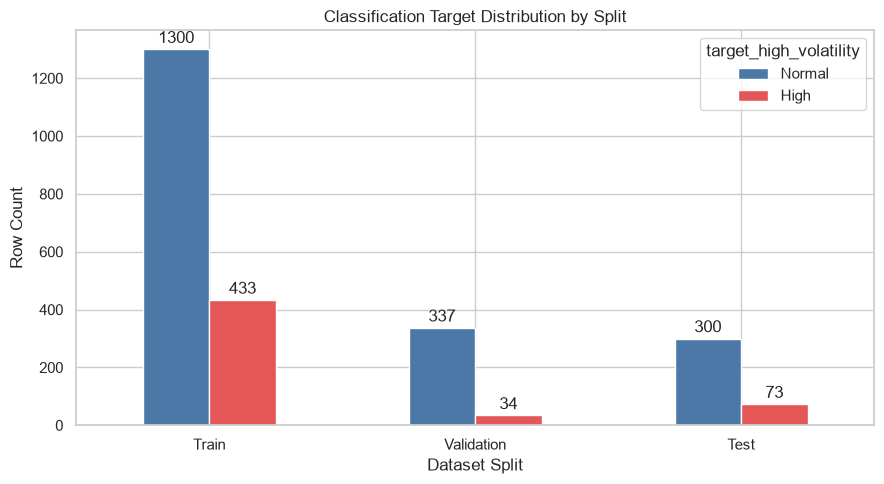

target_high_volatility,Normal,High
Train,1300,433
Validation,337,34
Test,300,73


target_high_volatility,Normal (%),High (%)
Train,75.014426,24.985574
Validation,90.835580,9.164420
Test,80.428954,19.571046


In [12]:
distribution = pd.DataFrame({
    name: frame[CLASSIFICATION_TARGET].value_counts().reindex([0, 1], fill_value=0)
    for name, frame in labeled_frames.items()
}).T.rename(columns={0: "Normal", 1: "High"})
ax = distribution.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
fig = ax.figure
ax.set_title("Classification Target Distribution by Split")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Row Count")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, padding=2)
fig.tight_layout()
output_path = figure_dir / "11_class_distribution_by_split.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

ratio_table = distribution.div(distribution.sum(axis=1), axis=0) * 100
display(distribution)
display(ratio_table.rename(columns=lambda column: f"{column} (%)"))

## 13. Modeling Data Quality

ตรวจเฉพาะ Features ทั้ง 8 ตัวและ Regression Target ที่โมเดลใช้

,NaN cells,Infinity cells
Train,0,0
Validation,0,0
Test,0,0


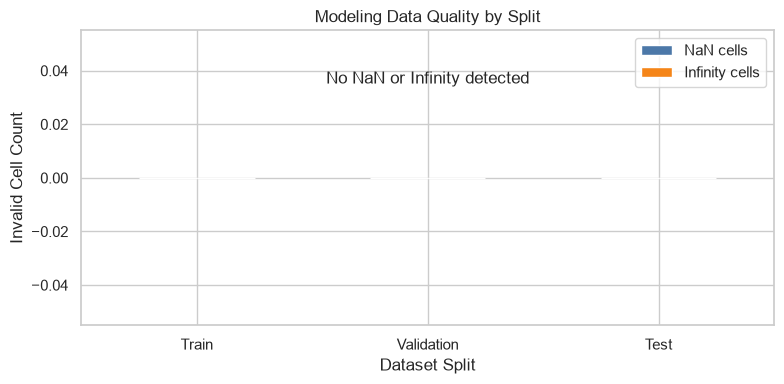

In [13]:
model_columns = [*FEATURE_COLUMNS, TARGET_COLUMN]
quality = pd.DataFrame({
    name: {
        "NaN cells": int(frame[model_columns].isna().sum().sum()),
        "Infinity cells": int(np.isinf(frame[model_columns].to_numpy(dtype=float)).sum()),
    }
    for name, frame in {"Train": datasets["train"], "Validation": datasets["validation"], "Test": datasets["test"]}.items()
}).T
display(quality)
assert (quality == 0).all(axis=None)

ax = quality.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
fig = ax.figure
ax.set_title("Modeling Data Quality by Split")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Invalid Cell Count")
ax.tick_params(axis="x", rotation=0)
ax.text(0.5, 0.82, "No NaN or Infinity detected", transform=ax.transAxes, ha="center")
fig.tight_layout()
output_path = figure_dir / "12_modeling_data_quality.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 14. Leakage Prevention Summary

| Potential leakage | Prevention in the current pipeline |
|---|---|
| Future returns entering Features | Feature windows are trailing and use information available through date t only |
| Q75 fitted with Validation/Test | Q75 is calculated from Train only and then locked |
| Random shuffle | Splits are chronological; no shuffle is used |
| Scaling before Split | No scaling has occurred; future modeling must fit any scaler on Train only |
| 5-day target window crossing split boundaries | Five modeling rows are purged between Train/Validation and Validation/Test |
| Target columns entering model Features | Modeling code must select only the eight `FEATURE_COLUMNS`, excluding both targets |

Overlapping target windows **within the same split** are expected; purging is specifically intended to prevent overlap across split boundaries

## 15. Final Data Preparation Summary

In [14]:
display(Markdown(
    f"""
- Source coverage: **{clean_df['Date'].min():%Y-%m-%d} to {clean_df['Date'].max():%Y-%m-%d}**
- Engineered features: **{len(FEATURE_COLUMNS)}**
- Regression target: **`{TARGET_COLUMN}`**
- Classification target: **`{CLASSIFICATION_TARGET}`**
- Train-only Q75: **{threshold:.16g}** ({threshold * 100:.6f}%)
- Split rows: Train **{len(datasets['train']):,}**, Validation **{len(datasets['validation']):,}**, Test **{len(datasets['test']):,}**
- Modeling-column NaN/Infinity: **0 / 0** in every split
- Controls: trailing features, train-only threshold, chronological split, and two five-row purging gaps

ขั้นตอนถัดไปคือ Modeling โดยยังไม่มี Scaling หรือ Model Training ใน Notebook นี้
"""
))


- Source coverage: **2016-08-31 to 2026-08-28**
- Engineered features: **8**
- Regression target: **`target_volatility_5d`**
- Classification target: **`target_high_volatility`**
- Train-only Q75: **0.2530580184684854** (25.305802%)
- Split rows: Train **1,733**, Validation **371**, Test **373**
- Modeling-column NaN/Infinity: **0 / 0** in every split
- Controls: trailing features, train-only threshold, chronological split, and two five-row purging gaps

ขั้นตอนถัดไปคือ Modeling โดยยังไม่มี Scaling หรือ Model Training ใน Notebook นี้


## Source Integrity Check

In [15]:
checksums_after = {name: sha256(path) for name, path in input_sources.items()}
checksum_audit = pd.DataFrame({"before": checksums_before, "after": checksums_after})
checksum_audit["unchanged"] = checksum_audit["before"] == checksum_audit["after"]
display(checksum_audit)
if not checksum_audit["unchanged"].all():
    changed = checksum_audit.index[~checksum_audit["unchanged"]].tolist()
    raise RuntimeError(f"Notebook changed input sources: {changed}")
print("All Notebook 2 input checksums are unchanged.")

,before,after,unchanged
clean_data,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...,062A7A57A55F0336F257B0CAE3425CB67E0DA0C30C4185...,True
feature_data,5020287D8A5D5963F9E0A894D5581D2174B513A1C0B493...,5020287D8A5D5963F9E0A894D5581D2174B513A1C0B493...,True
regression_target_data,557B6B2F6EDB560A9CF5F9A10208351C2C11BFAA00C49E...,557B6B2F6EDB560A9CF5F9A10208351C2C11BFAA00C49E...,True
train,E00CC9E500C463A46BBA3A986602B99D13B569237FB895...,E00CC9E500C463A46BBA3A986602B99D13B569237FB895...,True
validation,6B7E92C6A0C1FA3D150573C53B4D6DDE1FD7506C04F363...,6B7E92C6A0C1FA3D150573C53B4D6DDE1FD7506C04F363...,True
test,51E4719DEDF627129557147F67C9385C2B750AC409D919...,51E4719DEDF627129557147F67C9385C2B750AC409D919...,True
train_labeled,424F1BDA5C4211AC58546DA992408D373D874A0F65A509...,424F1BDA5C4211AC58546DA992408D373D874A0F65A509...,True
validation_labeled,B84A5FA31FE1AFC6841528F8E5F0C8532B07E2BDA8B80B...,B84A5FA31FE1AFC6841528F8E5F0C8532B07E2BDA8B80B...,True
test_labeled,5E8AC488CB895A8899ABD9B3AE9193B4DC6EBDA2E77B79...,5E8AC488CB895A8899ABD9B3AE9193B4DC6EBDA2E77B79...,True
feature_report,50E565284641E671A7C7958246D9D54E82294659B7A8EC...,50E565284641E671A7C7958246D9D54E82294659B7A8EC...,True


All Notebook 2 input checksums are unchanged.
